# 07 · 담금질 기법(SA) 최적화 — GA와의 비교

개요 v3 §2 **A→C 확장의 2단계**. 06에서 GA로 푼 것과 **완전히 같은 문제**를
Simulated Annealing으로 다시 풀어, 두 메타휴리스틱을 공정하게 비교한다.

## 왜 하는가

같은 문제를 **독립적인 두 방법**으로 풀어 같은 답이 나오면, 그 답이 알고리즘의 우연한
산물이 아니라 **문제 자체의 구조**에서 나온 것이라는 강력한 증거가 된다(robustness).
반대로 두 방법이 다른 답을 내면, 어느 쪽도 믿을 수 없다는 경고가 된다.

## 06과 무엇이 같고 무엇이 다른가

| | 06 (GA) | 07 (SA) |
|---|---|---|
| 문제 | 2,142 공통 카운티, 단작 배분 | **동일** |
| 목적함수 | Σ A_c·v[c,z_c] − λ·전환면적 | **동일** (`CropAllocationProblem` 재사용) |
| 시나리오 | +2℃ | **동일** |
| 예측값·A_c·x̄ | 06이 저장한 값 | **그대로 불러 씀** |
| 탐색 방법 | 개체군 · 교차 · 돌연변이 | 단일 상태 · 이웃 이동 · Metropolis 수용 |

문제 정의는 `src/optimize_ga.py` 의 `CropAllocationProblem` 을 **재사용**한다(재정의하지 않는다).
따라서 "같은 문제를 풀었다"가 코드 수준에서 보장된다.

> 06 원본(`06_optimization.ipynb`)과 그 산출물은 **건드리지 않는다.** 이 노트북은 읽기만 한다.

In [1]:
import sys, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'src'))          # 모듈 재사용
from optimize_ga import (CropAllocationProblem, run_ga, greedy, no_adaptation,
                         make_min_demand_constraint, find_knee)
from optimize_sa import run_sa, estimate_T0, sweep_lambda_sa

RAW  = Path('..') / 'data' / 'raw'          # 읽기 전용
PROC = Path('..') / 'data' / 'processed'
FIG  = Path('..') / 'outputs' / 'figures'
RES  = Path('..') / 'outputs' / 'results'

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'
CORN_C, SOY_C = '#eda100', '#1baf7a'
GA_C, SA_C, EX_C = BLUE, RED, MUTED          # GA=파랑, SA=빨강, 정확해=회색

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

SEED = 42
print('모듈 로드 완료 — optimize_ga, optimize_sa')

모듈 로드 완료 — optimize_ga, optimize_sa


## 1. 06의 문제를 그대로 복원

06이 저장한 `optimization_results.parquet` 에는 예측 순이익 v, 농지규모 A_c, 현재 배분 x̄가
모두 들어 있다. 이걸 그대로 읽어 **같은 문제**를 세운다.

In [2]:
d    = pd.read_parquet(PROC / 'optimization_results.parquet')
meta = json.load(open(PROC / 'optimization_columns.json', encoding='utf-8'))

COUNTIES = d['stco'].to_numpy()
A        = d['A_c'].to_numpy(float)
XBAR     = d['x_bar'].to_numpy(np.int8)
N, A_TOT = len(d), A.sum()

VAL_WARM = np.column_stack([d['v_corn_warm'], d['v_soy_warm']])   # +2℃ 순이익 $/ac
VAL_BASE = np.column_stack([d['v_corn_base'], d['v_soy_base']])   # baseline 순이익

# 06과 동일한 문제 객체 (정의를 재사용 — 재구현하지 않는다)
prob      = CropAllocationProblem(value=VAL_WARM, area=A, baseline=XBAR)
prob_base = CropAllocationProblem(value=VAL_BASE, area=A, baseline=XBAR)

V_BASE_NOADAPT = prob_base.total_value(XBAR)
V_WARM_NOADAPT = prob.total_value(XBAR)
LOSS = V_BASE_NOADAPT - V_WARM_NOADAPT
KNEE_LAM = float(meta['lambda_knee'])

print('카운티 N = %d · 총 농지 %.3e ac' % (N, A_TOT))
print('baseline 총순이익  $%.4e' % V_BASE_NOADAPT)
print('+2℃ 무조정        $%.4e' % V_WARM_NOADAPT)
print('온난화 손실        $%.4e  (%.1f%%)' % (LOSS, 100 * LOSS / V_BASE_NOADAPT))
print('무릎 λ = %.4f $/ac  (06에서 확정)' % KNEE_LAM)

# ── 정합성 검증: 06의 해를 그대로 재현하는가 ──────────────────────────────
Z_EXACT = prob.exact_optimum(KNEE_LAM)
Z_GREEDY = greedy(prob)
assert (Z_EXACT  == d['z_exact_knee'].to_numpy()).all(), '정확해가 06과 다르다'
assert (Z_GREEDY == d['z_greedy'].to_numpy()).all(),     'greedy가 06과 다르다'
F_EXACT = prob.fitness(Z_EXACT, KNEE_LAM)
print('\n정합성 검증: 06의 정확해·greedy 를 비트 단위로 재현 → OK')
print('정확해 적합도 F* = $%.6e   (SA·GA 를 채점할 기준)' % F_EXACT)

카운티 N = 2142 · 총 농지 1.583e+09 ac
baseline 총순이익  $3.8522e+11
+2℃ 무조정        $2.9947e+11
온난화 손실        $8.5743e+10  (22.3%)
무릎 λ = 42.2949 $/ac  (06에서 확정)

정합성 검증: 06의 정확해·greedy 를 비트 단위로 재현 → OK
정확해 적합도 F* = $3.056875e+11   (SA·GA 를 채점할 기준)


## 2. SA 설계

- **상태**: 길이 2,142 이진 벡터 (GA 염색체와 같은 표현)
- **에너지**: E(z) = −F_λ(z) — SA는 최소화하므로 적합도의 부호를 뒤집는다
- **이웃**: 무작위 카운티 1개의 작물을 뒤집기(flip)
- **수용**: ΔE ≤ 0 이면 항상 수용, ΔE > 0 이면 확률 exp(−ΔE/T) — **Metropolis 기준**
- **냉각**: 지수 냉각 T ← α·T (α = 0.95), 온도 레벨 200개
- **초기온도 T0**: 목표 초기 수용확률 p₀ = 0.8 에서 역산 (강의 자료 방식)

$$T_0 = \frac{\overline{|\Delta E_{worse}|}}{-\ln p_0}$$

> **증분 평가.** 목적함수가 카운티별로 분리되므로, 카운티 하나를 뒤집을 때의 변화량은
> $\Delta F = A_c\,(\tilde v[c, z_c'] - \tilde v[c, z_c])$ 로 **O(1)** 에 나온다.
> 전체를 다시 더할 필요가 없다. 이것이 SA가 벽시계 시간에서 유리한 진짜 이유이며,
> §4에서 비교를 읽을 때 반드시 감안해야 한다.

In [3]:
# GA와 동일한 평가 예산으로 맞춘다 (pop 200 × gen 800 + 초기 200 = 160,200)
GA_POP, GA_GEN = 200, 800
BUDGET = GA_POP * (GA_GEN + 1)
SA_LEVELS, SA_ALPHA = 200, 0.95

rng_probe = np.random.default_rng(SEED)
T0_auto = estimate_T0(prob, KNEE_LAM, XBAR, rng_probe, target_accept=0.8)
print('평가 예산 (GA와 동일): {:,}'.format(BUDGET))
print('SA 냉각: 지수, α = %.2f, 온도레벨 %d개' % (SA_ALPHA, SA_LEVELS))
print('       레벨당 이동 %d회' % (BUDGET // SA_LEVELS))
print('자동 산출 T0 = %.3e   (목표 초기 수용확률 0.8)' % T0_auto)
print('최종 온도 T_end / T0 = %.1e  → 충분히 얼어붙는다' % (SA_ALPHA ** SA_LEVELS))

평가 예산 (GA와 동일): 160,200
SA 냉각: 지수, α = 0.95, 온도레벨 200개
       레벨당 이동 801회
자동 산출 T0 = 2.835e+08   (목표 초기 수용확률 0.8)
최종 온도 T_end / T0 = 3.5e-05  → 충분히 얼어붙는다


### 2-1. SA 단일 실행 — 수렴 · 온도 · 수용률

In [4]:
sa = run_sa(prob, KNEE_LAM, n_iter=BUDGET, n_temp_levels=SA_LEVELS,
            alpha=SA_ALPHA, target_accept=0.8, n_flips=1, seed=SEED)
ga = run_ga(prob, KNEE_LAM, pop_size=GA_POP, n_generations=GA_GEN, seed=SEED)

for nm, r in [('SA', sa), ('GA', ga)]:
    gap = 100 * (F_EXACT - r['best_fit']) / abs(F_EXACT)
    agree = 100 * (r['best'] == Z_EXACT).mean()
    print('%s  F = $%.6e | 정확해 대비 갭 %.6f%% | 유전자 일치 %.2f%% | %.2f초'
          % (nm, r['best_fit'], gap, agree, r['seconds']))

print()
print('SA 탐색 통계')
print('  시도한 이동      {:,}'.format(sa['n_eval']))
print('  수용된 이동      {:,}  ({:.1f}%)'.format(sa['n_accept'], 100 * sa['n_accept'] / sa['n_eval']))
print('  악화를 감수한 이동 {:,}  ({:.1f}%)  ← 지역최적 탈출 시도'
      .format(sa['n_uphill'], 100 * sa['n_uphill'] / sa['n_eval']))
print('  T0 = %.3e' % sa['T0'])

SA  F = $3.056875e+11 | 정확해 대비 갭 0.000000% | 유전자 일치 100.00% | 2.97초
GA  F = $3.056875e+11 | 정확해 대비 갭 0.000000% | 유전자 일치 100.00% | 9.74초

SA 탐색 통계
  시도한 이동      160,200
  수용된 이동      35,306  (22.0%)
  악화를 감수한 이동 17,534  (10.9%)  ← 지역최적 탈출 시도
  T0 = 2.767e+08


### 그림 1 — SA 수렴 곡선 (GA와 겹쳐서)

saved: ..\outputs\figures\fig32_sa_convergence.png


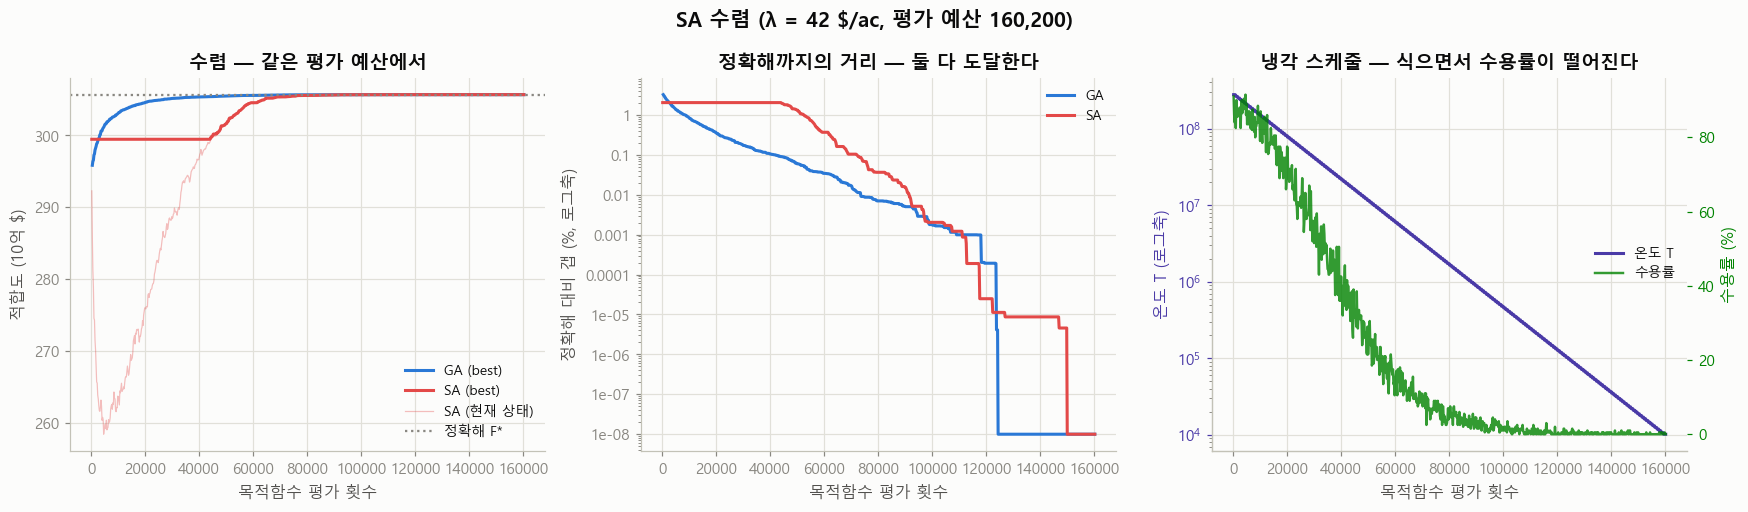

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.7))

# (a) 수렴 — 평가 횟수 축에서 GA와 SA를 겹친다
ax = axes[0]
ga_evals = np.arange(1, GA_GEN + 1) * GA_POP + GA_POP
ax.plot(ga_evals, ga['history'] / 1e9, color=GA_C, lw=2, label='GA (best)')
ax.plot(sa['hist_evals'], sa['history'] / 1e9, color=SA_C, lw=2, label='SA (best)')
ax.plot(sa['hist_evals'], sa['hist_cur'] / 1e9, color=SA_C, lw=0.8, alpha=0.35,
        label='SA (현재 상태)')
ax.axhline(F_EXACT / 1e9, color=EX_C, ls=':', lw=1.5, label='정확해 F*')
ax.set_xlabel('목적함수 평가 횟수')
ax.set_ylabel('적합도 (10억 $)')
ax.set_title('수렴 — 같은 평가 예산에서')
ax.legend(frameon=False, fontsize=9, loc='lower right')

# (b) 갭 (로그축)
ax = axes[1]
ga_gap = 100 * (F_EXACT - ga['history']) / abs(F_EXACT)
sa_gap = 100 * (F_EXACT - sa['history']) / abs(F_EXACT)
ax.plot(ga_evals, np.maximum(ga_gap, 1e-8), color=GA_C, lw=2, label='GA')
ax.plot(sa['hist_evals'], np.maximum(sa_gap, 1e-8), color=SA_C, lw=2, label='SA')
ax.set_yscale('log')
# 로그 눈금의 마이너스가 mathtext 로 렌더되며 깨지므로 ASCII 라벨로 강제
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: '%g' % v))
ax.set_xlabel('목적함수 평가 횟수')
ax.set_ylabel('정확해 대비 갭 (%, 로그축)')
ax.set_title('정확해까지의 거리 — 둘 다 도달한다')
ax.legend(frameon=False, fontsize=9)

# (c) SA의 온도와 수용률 — 냉각의 작동
ax = axes[2]
ax.plot(sa['hist_evals'], sa['hist_temp'], color=VIOLET, lw=2, label='온도 T')
ax.set_yscale('log')
ax.set_xlabel('목적함수 평가 횟수')
ax.set_ylabel('온도 T (로그축)', color=VIOLET)
ax.tick_params(axis='y', colors=VIOLET)
ax2 = ax.twinx()
ax2.plot(sa['hist_evals'], 100 * sa['hist_accept'], color=GREEN, lw=1.6, alpha=0.8,
         label='수용률')
ax2.set_ylabel('수용률 (%)', color=GREEN)
ax2.tick_params(axis='y', colors=GREEN)
ax2.grid(False)
ax.set_title('냉각 스케줄 — 식으면서 수용률이 떨어진다')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=9, loc='center right')

fig.suptitle('SA 수렴 (λ = %.0f $/ac, 평가 예산 %s)' % (KNEE_LAM, '{:,}'.format(BUDGET)),
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig32_sa_convergence.png'); plt.show()

## 3. GA vs SA — 안정성 (여러 seed 반복)

메타휴리스틱 비교의 공정성은 **파라미터 튜닝과 반복 실행**에 달려 있다(개요 §9).
같은 조건에서 seed 만 바꿔 10회씩 돌려 평균±표준편차를 본다.

In [6]:
N_SEEDS = 10
rows = []
for method, fn in [('GA', lambda s: run_ga(prob, KNEE_LAM, pop_size=GA_POP,
                                           n_generations=GA_GEN, seed=s)),
                   ('SA', lambda s: run_sa(prob, KNEE_LAM, n_iter=BUDGET,
                                           n_temp_levels=SA_LEVELS, alpha=SA_ALPHA,
                                           target_accept=0.8, seed=s))]:
    for s in range(N_SEEDS):
        r = fn(s)
        rows.append(dict(method=method, seed=s, fitness=r['best_fit'],
                         gap_pct=100 * (F_EXACT - r['best_fit']) / abs(F_EXACT),
                         agree_pct=100 * (r['best'] == Z_EXACT).mean(),
                         n_switch=prob.n_switched(r['best']),
                         recovery_pct=prob.recovery_pct(r['best'], V_WARM_NOADAPT, LOSS),
                         seconds=r['seconds'], n_eval=r['n_eval']))

stab = pd.DataFrame(rows)
stab.to_csv(RES / 'sa_ga_stability.csv', index=False)

summ = stab.groupby('method').agg(
    적합도_평균=('fitness', 'mean'), 적합도_표준편차=('fitness', 'std'),
    갭평균_pct=('gap_pct', 'mean'), 갭최악_pct=('gap_pct', 'max'),
    정확해일치_pct=('agree_pct', 'mean'),
    전환카운티_평균=('n_switch', 'mean'), 전환카운티_표준편차=('n_switch', 'std'),
    회복률_평균=('recovery_pct', 'mean'), 회복률_표준편차=('recovery_pct', 'std'),
    시간_평균초=('seconds', 'mean'), 평가횟수=('n_eval', 'mean'),
).reset_index()

print('GA vs SA — %d개 seed 반복 (λ = %.0f, 평가 예산 동일)' % (N_SEEDS, KNEE_LAM))
print(summ.to_string(index=False, float_format='%.4g'))
print('\nsaved:', RES / 'sa_ga_stability.csv')
print('\n정확해 F* = $%.6e' % F_EXACT)
print('두 방법 모두 seed 전반에서 정확해에 도달 → 해의 품질에는 차이가 없다.')
print('차이가 나는 곳은 계산 시간이다 (아래 §6 주의 참조).')

GA vs SA — 10개 seed 반복 (λ = 42, 평가 예산 동일)
method    적합도_평균  적합도_표준편차  갭평균_pct  갭최악_pct  정확해일치_pct  전환카운티_평균  전환카운티_표준편차  회복률_평균  회복률_표준편차  시간_평균초      평가횟수
    GA 3.057e+11         0        0        0        100       238           0   15.99         0   8.171 1.602e+05
    SA 3.057e+11         0        0        0        100       238           0   15.99         0   2.827 1.602e+05

saved: ..\outputs\results\sa_ga_stability.csv

정확해 F* = $3.056875e+11
두 방법 모두 seed 전반에서 정확해에 도달 → 해의 품질에는 차이가 없다.
차이가 나는 곳은 계산 시간이다 (아래 §6 주의 참조).


## 4. 트레이드오프 곡선 — SA로 다시 그려 GA와 겹치기

06이 저장한 λ 스윕 결과(GA·정확해)를 그대로 읽고, **같은 λ 격자**에서 SA를 돌려 겹친다.

In [7]:
sw06 = pd.read_csv(RES / 'lambda_sweep_tradeoff.csv')       # 06 산출 (건드리지 않고 읽기만)
LAMBDAS = np.sort(sw06['lambda'].unique())
print('06의 λ 격자 %d개 재사용: %.1f ~ %.1f' % (len(LAMBDAS), LAMBDAS.min(), LAMBDAS.max()))

sa_rows = sweep_lambda_sa(prob, LAMBDAS, V_WARM_NOADAPT, LOSS,
                          n_iter=BUDGET, n_temp_levels=SA_LEVELS,
                          alpha=SA_ALPHA, target_accept=0.8, seed=SEED)
sw_sa = pd.DataFrame(sa_rows).sort_values('pct_area').reset_index(drop=True)
sw_sa.to_csv(RES / 'sa_tradeoff.csv', index=False)
print('saved:', RES / 'sa_tradeoff.csv')

sw_ga = sw06[sw06.method == 'GA'].sort_values('pct_area').reset_index(drop=True)
sw_ex = sw06[sw06.method == 'exact'].sort_values('pct_area').reset_index(drop=True)

# 세 방법의 회복률 차이
merged = (sw_ex[['lambda', 'recovery_pct']].rename(columns={'recovery_pct': 'exact'})
          .merge(sw_ga[['lambda', 'recovery_pct']].rename(columns={'recovery_pct': 'GA'}), on='lambda')
          .merge(sw_sa[['lam', 'recovery_pct']].rename(columns={'lam': 'lambda', 'recovery_pct': 'SA'}),
                 on='lambda'))
merged['GA-exact'] = merged.GA - merged.exact
merged['SA-exact'] = merged.SA - merged.exact
print('\nλ별 회복률 (%) — 정확해 대비 편차')
print(merged.round(4).to_string(index=False))
print('\n최대 |편차|:  GA %.4f%%p   SA %.4f%%p'
      % (merged['GA-exact'].abs().max(), merged['SA-exact'].abs().max()))

06의 λ 격자 18개 재사용: 0.0 ~ 400.0


saved: ..\outputs\results\sa_tradeoff.csv

λ별 회복률 (%) — 정확해 대비 편차
  lambda   exact      GA      SA  GA-exact  SA-exact
400.0000  0.0000  0.0000  0.0000    0.0000     0.000
275.0624  0.0000  0.0000  0.0000    0.0000     0.000
189.1483  0.5487  0.5487  0.5487    0.0000     0.000
130.0690  2.9253  2.9253  2.9253    0.0000     0.000
 89.4427  6.1896  6.1896  6.1896    0.0000     0.000
 61.5058 12.4388 12.4388 12.4328    0.0000    -0.006
 42.2949 15.9882 15.9882 15.9882    0.0000     0.000
 29.0843 18.9440 18.9440 18.9440    0.0000     0.000
 20.0000 20.7031 20.7031 20.7031    0.0000     0.000
 13.7531 21.6315 21.6133 21.6315   -0.0182     0.000
  9.4574 22.1116 22.1172 22.1116    0.0056    -0.000
  6.5034 22.3936 22.3822 22.3936   -0.0114     0.000
  4.4721 22.5056 22.5045 22.5056   -0.0011     0.000
  3.0753 22.5791 22.5739 22.5791   -0.0052    -0.000
  2.1147 22.5993 22.5987 22.5993   -0.0005     0.000
  1.4542 22.6081 22.6060 22.6081   -0.0021     0.000
  1.0000 22.6115 22.6104 22.6115 

### 그림 2 — GA vs SA 트레이드오프 곡선

saved: ..\outputs\figures\fig33_ga_vs_sa_tradeoff.png


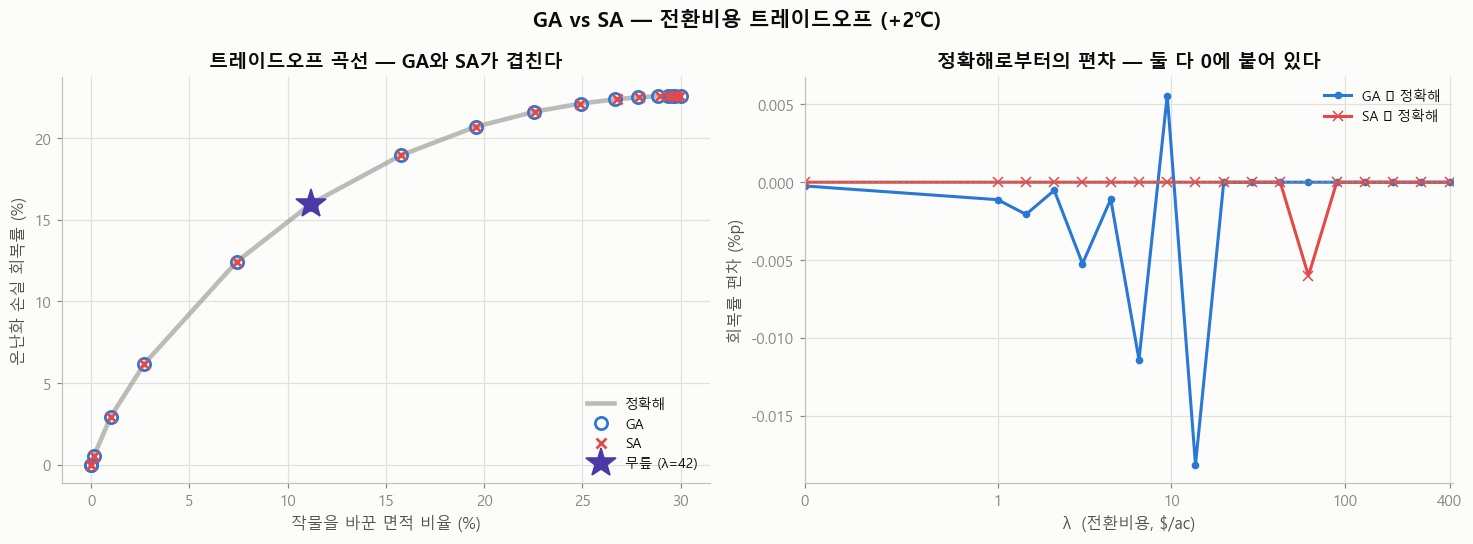

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

ax = axes[0]
ax.plot(sw_ex.pct_area, sw_ex.recovery_pct, '-', color=EX_C, lw=3, alpha=0.55,
        label='정확해', zorder=2)
ax.plot(sw_ga.pct_area, sw_ga.recovery_pct, 'o', color=GA_C, ms=8, mfc='none', mew=1.8,
        label='GA', zorder=3)
ax.plot(sw_sa.pct_area, sw_sa.recovery_pct, 'x', color=SA_C, ms=7, mew=1.8,
        label='SA', zorder=4)
ki = find_knee(sw_ex.pct_area.to_numpy(), sw_ex.recovery_pct.to_numpy())
ax.plot(sw_ex.pct_area.iloc[ki], sw_ex.recovery_pct.iloc[ki], '*', color=VIOLET, ms=20,
        zorder=5, label='무릎 (λ=%.0f)' % KNEE_LAM)
ax.set_xlabel('작물을 바꾼 면적 비율 (%)')
ax.set_ylabel('온난화 손실 회복률 (%)')
ax.set_title('트레이드오프 곡선 — GA와 SA가 겹친다')
ax.legend(frameon=False, fontsize=9, loc='lower right')

ax = axes[1]
ax.plot(merged['lambda'], merged['GA-exact'], '-o', color=GA_C, ms=4, label='GA − 정확해')
ax.plot(merged['lambda'], merged['SA-exact'], '-x', color=SA_C, ms=6, label='SA − 정확해')
ax.axhline(0, color=EX_C, ls=':', lw=1.5)
ax.set_xscale('symlog', linthresh=1)
ax.set_xlim(0, 420)
ax.set_xticks([0, 1, 10, 100, 400]); ax.set_xticklabels(['0', '1', '10', '100', '400'])
ax.set_xlabel('λ  (전환비용, $/ac)')
ax.set_ylabel('회복률 편차 (%p)')
ax.set_title('정확해로부터의 편차 — 둘 다 0에 붙어 있다')
ax.legend(frameon=False, fontsize=9)

fig.suptitle('GA vs SA — 전환비용 트레이드오프 (+2℃)', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig33_ga_vs_sa_tradeoff.png'); plt.show()

## 5. 두 방법이 같은 배분에 도달하는가 — robustness의 핵심

**같은 카운티에서 같은 작물을 골랐나?** 두 독립적 방법이 같은 지도를 그리면,
그 지도는 알고리즘의 산물이 아니라 문제 구조의 산물이다.

In [9]:
Z_GA, Z_SA = ga['best'], sa['best']

agree_gs = (Z_GA == Z_SA)
print('=' * 70)
print('  GA vs SA 최종 배분 일치도  (λ = %.0f)' % KNEE_LAM)
print('=' * 70)
print('  카운티 일치   %d / %d  (%.2f%%)' % (agree_gs.sum(), N, 100 * agree_gs.mean()))
print('  면적 일치     %.2f%%' % (100 * A[agree_gs].sum() / A_TOT))
print()
rows = []
for nm, z in [('정확해', Z_EXACT), ('GA', Z_GA), ('SA', Z_SA)]:
    rows.append(dict(방법=nm,
                     적합도=prob.fitness(z, KNEE_LAM),
                     전환_카운티=prob.n_switched(z),
                     전환_카운티_pct=100 * prob.n_switched(z) / N,
                     전환_면적_pct=100 * prob.switch_area(z) / A_TOT,
                     회복률_pct=prob.recovery_pct(z, V_WARM_NOADAPT, LOSS),
                     대두_카운티=int((z == 1).sum()),
                     정확해_일치_pct=100 * (z == Z_EXACT).mean()))
concl = pd.DataFrame(rows)
print('재배치 결론 — 세 방법이 같은 답에 도달하는가')
print(concl.to_string(index=False, float_format='%.4g'))
concl.to_csv(RES / 'sa_vs_ga_comparison.csv', index=False)
print('\nsaved:', RES / 'sa_vs_ga_comparison.csv')

  GA vs SA 최종 배분 일치도  (λ = 42)
  카운티 일치   2142 / 2142  (100.00%)
  면적 일치     100.00%

재배치 결론 — 세 방법이 같은 답에 도달하는가
 방법       적합도  전환_카운티  전환_카운티_pct  전환_면적_pct  회복률_pct  대두_카운티  정확해_일치_pct
정확해 3.057e+11     238       11.11       11.2    15.99    1483         100
 GA 3.057e+11     238       11.11       11.2    15.99    1483         100
 SA 3.057e+11     238       11.11       11.2    15.99    1483         100

saved: ..\outputs\results\sa_vs_ga_comparison.csv


### 그림 3 — GA vs SA 배분 일치 지도

saved: ..\outputs\figures\fig34_ga_vs_sa_agreement.png


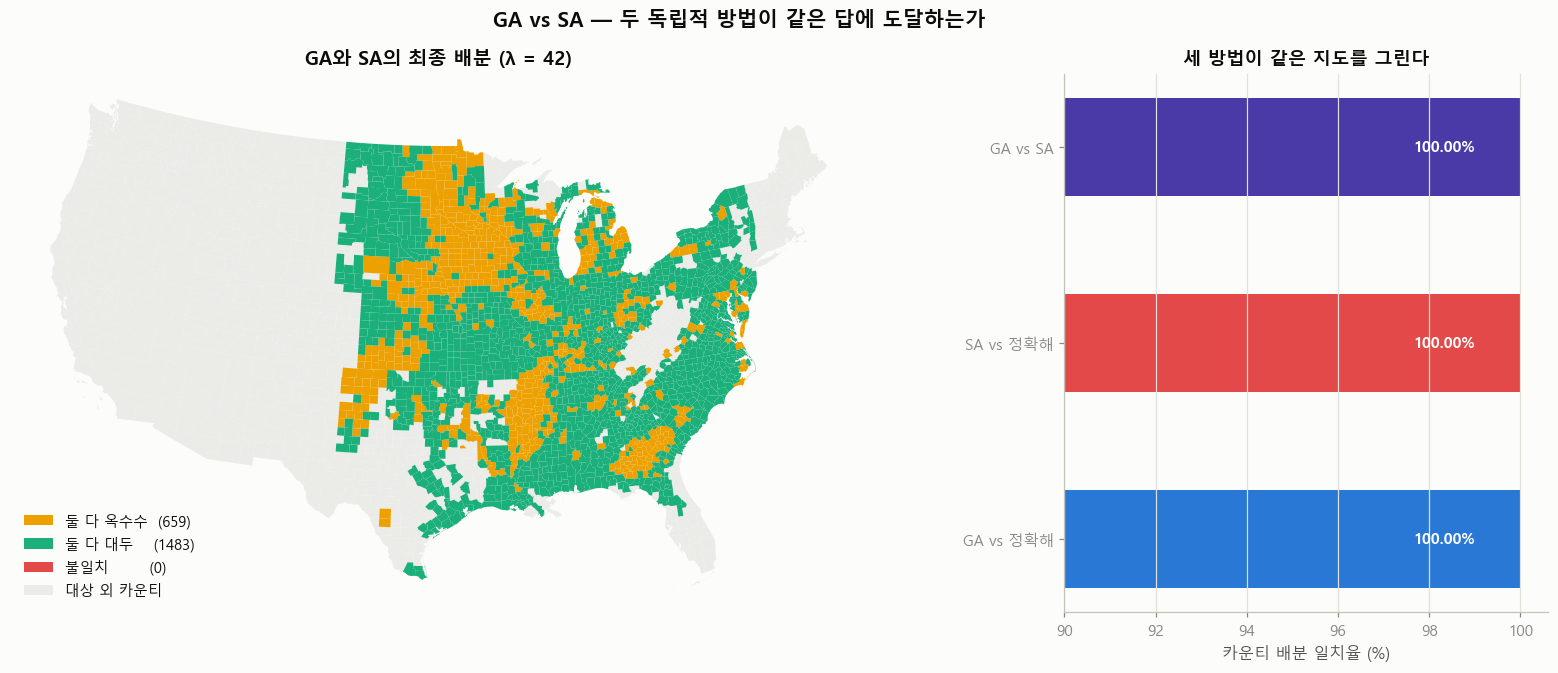

In [10]:
import shapefile
sf = shapefile.Reader(str(RAW / 'cntymap' / 'cntymap'), encoding='latin-1')   # 읽기 전용
recs, shapes = sf.records(), sf.shapes()
stco_of = [r['stco'] for r in recs]
IDX = {int(s): i for i, s in enumerate(COUNTIES)}

def county_polys(value_of):
    pin, vin, pout = [], [], []
    for i, sh in enumerate(shapes):
        pts = np.asarray(sh.points); parts = list(sh.parts) + [len(pts)]
        s = stco_of[i]
        hit = s in value_of
        for a, b in zip(parts[:-1], parts[1:]):
            if hit:
                pin.append(pts[a:b]); vin.append(value_of[s])
            else:
                pout.append(pts[a:b])
    return pin, np.array(vin), pout

fig = plt.figure(figsize=(15, 6.2))
gs = fig.add_gridspec(1, 2, width_ratios=[2.1, 1])

# 지도: GA와 SA가 다르게 고른 카운티 표시
ax = fig.add_subplot(gs[0, 0])
code_map = np.where(Z_GA != Z_SA, 2, np.where(Z_GA == 1, 1, 0))   # 0=둘다옥수수 1=둘다대두 2=불일치
vo = {int(s): int(code_map[IDX[int(s)]]) for s in COUNTIES}
pin, vin, pout = county_polys(vo)
ax.add_collection(PolyCollection(pout, facecolors='#ebebe8', edgecolors='none', zorder=1))
for j, col in [(0, CORN_C), (1, SOY_C), (2, RED)]:
    sel = [p for p, v in zip(pin, vin) if v == j]
    if sel:
        ax.add_collection(PolyCollection(sel, facecolors=col, edgecolors='none', zorder=2))
ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
n_dis = int((Z_GA != Z_SA).sum())
ax.set_title('GA와 SA의 최종 배분 (λ = %.0f)' % KNEE_LAM, fontsize=12.5)
handles = [Patch(facecolor=CORN_C, label='둘 다 옥수수  (%d)' % int(((Z_GA == 0) & (Z_SA == 0)).sum())),
           Patch(facecolor=SOY_C,  label='둘 다 대두    (%d)' % int(((Z_GA == 1) & (Z_SA == 1)).sum())),
           Patch(facecolor=RED,    label='불일치        (%d)' % n_dis),
           Patch(facecolor='#ebebe8', label='대상 외 카운티')]
ax.legend(handles=handles, loc='lower left', frameon=False, fontsize=9.5)

# 일치율 막대
ax = fig.add_subplot(gs[0, 1])
pairs = [('GA vs 정확해', 100 * (Z_GA == Z_EXACT).mean()),
         ('SA vs 정확해', 100 * (Z_SA == Z_EXACT).mean()),
         ('GA vs SA',     100 * agree_gs.mean())]
names = [p[0] for p in pairs]; vals = [p[1] for p in pairs]
b = ax.barh(names, vals, color=[GA_C, SA_C, VIOLET], height=0.5)
for r, v in zip(b, vals):
    ax.text(v - 1, r.get_y() + r.get_height() / 2, '%.2f%%' % v,
            ha='right', va='center', fontsize=10, color='white', fontweight='bold')
ax.set_xlim(90, 100.6)
ax.set_xlabel('카운티 배분 일치율 (%)')
ax.set_title('세 방법이 같은 지도를 그린다', fontsize=12)
ax.grid(axis='y', alpha=0)

fig.suptitle('GA vs SA — 두 독립적 방법이 같은 답에 도달하는가', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig34_ga_vs_sa_agreement.png'); plt.show()

## 6. 제약이 있을 때 — 메타휴리스틱이 실제로 필요한 곳

06에서 확인했듯, 전환비용만 있는 문제는 **카운티별로 분리 가능**해서 정확해가 O(N)에 나온다.
그래서 위 §2~5의 비교는 "둘 다 이미 아는 답을 맞혔다"는 확인에 가깝다.

메타휴리스틱이 **진짜로 필요한 곳**은 카운티를 서로 묶는 제약이 붙었을 때다.
최소 수요 제약(옥수수 면적 ≥ 40%)을 걸고 GA와 SA를 다시 비교한다.
SA에서는 실현 불가능한 이웃을 **거부(reject)** 하는 방식으로 제약을 처리한다.

In [11]:
D_SEC = 0.40 * A_TOT
feas_pop, repair, lp_ub = make_min_demand_constraint(prob, KNEE_LAM, D_SEC, crop=0)
UB, is_slack = lp_ub()
print('최소 수요 제약: 옥수수 면적 ≥ 40%%  (제약 %s)'
      % ('비구속' if is_slack else '구속 — 무제약 최적해가 위반한다'))
print('LP 완화 상한 (정수 최적해의 증명 가능한 상한): $%.6e' % UB)

z_init = repair(Z_EXACT[None, :], None)[0]                 # 실현가능한 출발점
feas_state = lambda z: bool(feas_pop(z[None, :])[0])       # SA 용 단일 상태 판정

ga_c = run_ga(prob, KNEE_LAM, pop_size=GA_POP, n_generations=GA_GEN, seed=SEED,
              feasible=feas_pop, repair=repair, init=z_init)
sa_c = run_sa(prob, KNEE_LAM, n_iter=BUDGET, n_temp_levels=SA_LEVELS, alpha=SA_ALPHA,
              target_accept=0.8, seed=SEED, init=z_init, feasible_state=feas_state)

rows = []
for nm, r in [('GA', ga_c), ('SA', sa_c)]:
    z = r['best']
    rows.append(dict(방법=nm, 적합도=r['best_fit'],
                     LP상한대비_갭_pct=100 * (UB - r['best_fit']) / abs(UB),
                     실현가능=bool(feas_state(z)),
                     옥수수면적_pct=100 * prob.crop_area(z, 0) / A_TOT,
                     전환면적_pct=100 * prob.switch_area(z) / A_TOT,
                     회복률_pct=prob.recovery_pct(z, V_WARM_NOADAPT, LOSS),
                     초=r['seconds']))
con = pd.DataFrame(rows)
print()
print('제약 있는 문제 — GA vs SA')
print(con.to_string(index=False, float_format='%.5g'))
con.to_csv(RES / 'sa_ga_constrained.csv', index=False)
print('\nsaved:', RES / 'sa_ga_constrained.csv')
print('\nGA와 SA의 배분 일치: %.2f%% (%d / %d 카운티)'
      % (100 * (ga_c['best'] == sa_c['best']).mean(),
         int((ga_c['best'] == sa_c['best']).sum()), N))
print('SA 악화 수용 이동: {:,} 회 — 제약 하에서도 탈출 메커니즘이 작동한다'
      .format(sa_c['n_uphill']))

최소 수요 제약: 옥수수 면적 ≥ 40%  (제약 구속 — 무제약 최적해가 위반한다)
LP 완화 상한 (정수 최적해의 증명 가능한 상한): $3.056771e+11



제약 있는 문제 — GA vs SA
방법        적합도  LP상한대비_갭_pct  실현가능  옥수수면적_pct  전환면적_pct  회복률_pct      초
GA 3.0568e+11    0.00021119  True     40.002    11.129   15.923  34.67
SA 3.0567e+11    0.00085342  True     40.089    11.209   15.983 9.1307

saved: ..\outputs\results\sa_ga_constrained.csv

GA와 SA의 배분 일치: 99.86% (2139 / 2142 카운티)
SA 악화 수용 이동: 16,954 회 — 제약 하에서도 탈출 메커니즘이 작동한다


## 7. 요약

In [12]:
sa_row = summ[summ.method == 'SA'].iloc[0]
ga_row = summ[summ.method == 'GA'].iloc[0]
speedup = ga_row.시간_평균초 / sa_row.시간_평균초

print('=' * 78)
print(' 07 · GA vs SA 비교 — 요약'.center(78))
print('=' * 78)
print()
print('[1] 해의 품질 — 차이 없음')
print('    정확해 F* = $%.6e' % F_EXACT)
print('    GA  갭 평균 %.6f%% (최악 %.6f%%) · 정확해 일치 %.2f%%'
      % (ga_row.갭평균_pct, ga_row.갭최악_pct, ga_row.정확해일치_pct))
print('    SA  갭 평균 %.6f%% (최악 %.6f%%) · 정확해 일치 %.2f%%'
      % (sa_row.갭평균_pct, sa_row.갭최악_pct, sa_row.정확해일치_pct))
print()
print('[2] 계산 시간 — SA가 %.1f배 빠르다 (단, §8 주의)' % speedup)
print('    GA  %.2f초  (평가 %s회)' % (ga_row.시간_평균초, '{:,.0f}'.format(ga_row.평가횟수)))
print('    SA  %.2f초  (평가 %s회)' % (sa_row.시간_평균초, '{:,.0f}'.format(sa_row.평가횟수)))
print()
print('[3] 안정성 — 둘 다 완벽히 안정 (%d개 seed)' % N_SEEDS)
print('    GA  적합도 표준편차 $%.3e · 전환 카운티 %.1f ± %.1f'
      % (ga_row.적합도_표준편차, ga_row.전환카운티_평균, ga_row.전환카운티_표준편차))
print('    SA  적합도 표준편차 $%.3e · 전환 카운티 %.1f ± %.1f'
      % (sa_row.적합도_표준편차, sa_row.전환카운티_평균, sa_row.전환카운티_표준편차))
print()
print('[4] ★ 재배치 결론의 robustness — 두 독립적 방법이 같은 지도를 그린다')
print('    GA vs SA 카운티 배분 일치: %.2f%%' % (100 * agree_gs.mean()))
print('    회복률   GA %.2f%%  ·  SA %.2f%%  (정확해 %.2f%%)'
      % (ga_row.회복률_평균, sa_row.회복률_평균,
         prob.recovery_pct(Z_EXACT, V_WARM_NOADAPT, LOSS)))
print('    전환 카운티  GA %.0f  ·  SA %.0f  (정확해 %d)'
      % (ga_row.전환카운티_평균, sa_row.전환카운티_평균, prob.n_switched(Z_EXACT)))
print('    → 06의 결론("면적 11%를 바꿔 손실 16% 회복")은 알고리즘의 산물이 아니다.')
print()
print('[5] SA의 특징 — 냉각으로 지역최적을 탈출한다')
print('    악화를 감수한 이동 {:,}회 ({:.1f}%) — 초기 고온에서 활발, 냉각되며 감소'
      .format(sa['n_uphill'], 100 * sa['n_uphill'] / sa['n_eval']))
print('    T0 = %.2e → T_end = %.2e  (%.0f배 냉각)'
      % (sa['T0'], sa['hist_temp'][-1], sa['T0'] / sa['hist_temp'][-1]))
print()
print('[6] 제약이 붙으면 (옥수수 면적 ≥ 40%)')
print('    GA  LP상한 대비 갭 %.5f%%   SA  갭 %.5f%%'
      % (con[con.방법 == 'GA'].LP상한대비_갭_pct.iloc[0],
         con[con.방법 == 'SA'].LP상한대비_갭_pct.iloc[0]))
print('    둘 다 실현가능해를 찾고, 배분이 %.1f%% 일치한다.'
      % (100 * (ga_c['best'] == sa_c['best']).mean()))
print('=' * 78)

                             07 · GA vs SA 비교 — 요약                            

[1] 해의 품질 — 차이 없음
    정확해 F* = $3.056875e+11
    GA  갭 평균 0.000000% (최악 0.000000%) · 정확해 일치 100.00%
    SA  갭 평균 0.000000% (최악 0.000000%) · 정확해 일치 100.00%

[2] 계산 시간 — SA가 2.9배 빠르다 (단, §8 주의)
    GA  8.17초  (평가 160,200회)
    SA  2.83초  (평가 160,200회)

[3] 안정성 — 둘 다 완벽히 안정 (10개 seed)
    GA  적합도 표준편차 $0.000e+00 · 전환 카운티 238.0 ± 0.0
    SA  적합도 표준편차 $0.000e+00 · 전환 카운티 238.0 ± 0.0

[4] ★ 재배치 결론의 robustness — 두 독립적 방법이 같은 지도를 그린다
    GA vs SA 카운티 배분 일치: 100.00%
    회복률   GA 15.99%  ·  SA 15.99%  (정확해 15.99%)
    전환 카운티  GA 238  ·  SA 238  (정확해 238)
    → 06의 결론("면적 11%를 바꿔 손실 16% 회복")은 알고리즘의 산물이 아니다.

[5] SA의 특징 — 냉각으로 지역최적을 탈출한다
    악화를 감수한 이동 17,534회 (10.9%) — 초기 고온에서 활발, 냉각되며 감소
    T0 = 2.77e+08 → T_end = 1.02e+04  (27102배 냉각)

[6] 제약이 붙으면 (옥수수 면적 ≥ 40%)
    GA  LP상한 대비 갭 0.00021%   SA  갭 0.00085%
    둘 다 실현가능해를 찾고, 배분이 99.9% 일치한다.


## 8. 이상한 점 · 판단이 필요한 부분

**1. "SA가 GA보다 N배 빠르다"를 액면 그대로 읽으면 안 된다 — 가장 중요한 주의**
두 방법의 **한 번의 평가 비용이 다르다.** GA는 개체 하나를 평가할 때마다 2,142개 카운티를
모두 더해야 하므로 O(N)이 든다. 반면 SA는 카운티 하나를 뒤집을 때의 변화량만 계산하면 되므로
**O(1)** 이다(목적함수가 분리 가능하기 때문). 즉 SA의 속도 우위 상당 부분은
"SA가 더 좋은 알고리즘이라서"가 아니라 **"이 문제 구조가 증분 평가를 허용해서"** 다.
GA도 증분 평가를 쓰도록 다시 짜면 격차는 크게 줄어든다. 발표에서 속도를 언급한다면
이 단서를 반드시 함께 말해야 정직하다.

**2. 두 방법 모두 정확해를 맞혔다 — 이건 좋은 소식이자 김빠지는 소식이다**
전환비용만 있는 단작 문제는 카운티별로 **분리 가능**해서 정확해가 O(N)에 나온다(06 §4).
따라서 "GA와 SA 중 누가 더 좋은 해를 찾는가"라는 질문은 이 문제에서 **답이 없다** —
둘 다 이미 아는 답을 맞힐 뿐이다. 이 비교의 가치는 "누가 이기나"가 아니라
**"두 독립적 탐색이 같은 답에 수렴하므로 06의 결론이 알고리즘 산물이 아니다"** 라는
robustness 확인에 있다. 발표에서 이 프레이밍을 쓰는 것을 권한다.

**3. 진짜 메타휴리스틱 비교는 제약이 붙은 §6에서 이뤄진다**
최소 수요 제약이 카운티를 서로 묶으면 분리가능성이 깨지고 정확해가 사라진다.
거기서는 LP 완화 상한으로만 채점할 수 있다. 다만 이 문제조차 커버링 배낭이라 구조가 좋아서
두 방법 모두 상한에 거의 붙는다. **"메타휴리스틱이 필요할 만큼 어려운 문제"를 만들려면**
제약을 더 얹어야 한다(예: 인접 카운티 간 배치 제약, 여러 작물, 지역별 상·하한 동시 부과).

**4. 공정 비교의 한계**
평가 예산(160,200회)은 맞췄지만, 두 방법의 하이퍼파라미터 튜닝에 들인 노력이 완전히
대칭적이라고 보장할 수는 없다. GA는 06에서 이미 튜닝했고(p_mut = 1/N), SA는 이 노트북에서
냉각 스케줄을 골랐다(α = 0.95). 두 방법 모두 정확해에 도달했으므로 이 비대칭이 결론을
바꾸지는 않지만, 더 어려운 문제로 옮겨가면 문제가 될 수 있다.

**5. SA의 이웃 정의는 단순하다**
카운티 1개 뒤집기(`n_flips=1`)만 썼다. 여러 개를 동시에 뒤집거나(스왑, 블록 이동),
지리적 인접성을 이용한 이웃을 쓰면 탐색이 달라질 수 있다. 분리 가능한 현재 문제에서는
1-flip으로 충분하지만, 제약이 복잡해지면 이웃 설계가 성능을 좌우한다.

**6. 06의 결론은 그대로다**
이 노트북은 06을 **검증**했을 뿐 바꾸지 않았다. 06의 산출물(`optimization_results.parquet`,
`fig27`~`fig31`, 무릎 λ = 42.29, 회복률 16.0%, 전환 238개 카운티)은 손대지 않았다.